## Persistent Homology Analysis of Fire Station Coverage in LA County

**Method:** Persistent Homology via Vietoris-Rips Complex (primary) + Witness Complex (validation)  


### Topological Interpretation
| Feature | Meaning |
|---|---|
| **H0** (connected components) | Long-lived bar → isolated station cluster far from others → sparse coverage zone |
| **H1** (1-cycles / loops) | Long-lived bar → topological void: stations encircle a region with none inside → coverage gap |


In [1]:
# Run once; restart kernel afterwards if installing for the first time
# %pip install gudhi geopandas pyproj shapely scipy matplotlib pandas

### Step 1 — Imports & Load Data

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import geopandas as gpd
import gudhi
from shapely.ops import unary_union
from scipy.spatial.distance import pdist, squareform, cdist
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.collections import PolyCollection, LineCollection

# ── Paths (adjust if your files are in a different directory) ──
STATIONS_PATH  = "../../data/all_stations.geojson"
LA_COUNTY_PATH = "../../data/la_county_svi.geojson"

# ── Filtration parameters ──
RIPS_MAX_M          = 25_000   # 25 km — maximum Rips edge length
N_LANDMARKS         = 80       # 20 % of stations used as Witness landmarks
H1_SIG_THRESHOLD_M  = 3_000   # 3 km min persistence to call H1 void "significant"

# ── Operational evaluation radii (km → converted to m below) ──
# Based on NFPA 1710 (urban) and wildfire staging distances
EVAL_RADII_KM = [2, 4, 6, 8, 10, 15, 20]
EVAL_RADII_M  = [r * 1000 for r in EVAL_RADII_KM]

# ── Neighborhood vulnerability weights ──
W_DIST    = 0.50   # weight: min distance to nearest station
W_BETA1   = 0.30   # weight: local H1 count
W_DENSITY = 0.20   # weight: (1 - normalised station density)

# ── Coordinate reference systems ──
CRS_WGS84 = "EPSG:4326"    # input: WGS84 lon/lat
CRS_UTM   = "EPSG:32611"   # projected: UTM Zone 11N (LA County)


### Step 2 — Load Dataset

We load two datasets:
- **`all_stations.geojson`** — 412 fire station points (LAFD, LACoFD, municipal)
- **`la_county_svi.geojson`** — 272 named neighborhood polygons covering LA County

In [3]:
# ── Load fire stations ──
stations_wgs = gpd.read_file(STATIONS_PATH).set_crs(CRS_WGS84, allow_override=True)

print(f"Stations loaded : {len(stations_wgs)}")
print(f"  LAFD          : {(stations_wgs['department'] == 'LAFD').sum()}")
print(f"  LACoFD        : {(stations_wgs['department'] == 'LACoFD').sum()}")
print(f"  Other         : {(~stations_wgs['department'].isin(['LAFD','LACoFD'])).sum()}")

Stations loaded : 412
  LAFD          : 106
  LACoFD        : 172
  Other         : 134


In [4]:
# ── Load LA County neighborhoods ──
county_wgs = gpd.read_file(LA_COUNTY_PATH).set_crs(CRS_WGS84, allow_override=True)

print(f"Neighborhoods loaded : {len(county_wgs)}")

Neighborhoods loaded : 272


### Step 3 — Clip Stations to LA County Boundary and project to UTM Zone 11N

Some stations in the raw dataset may fall just outside the county boundary. We keep only those geometrically within the county union.

In [5]:
county_boundary = unary_union(county_wgs.geometry)
within_mask     = stations_wgs.geometry.within(county_boundary)
stations_clipped = stations_wgs[within_mask].copy().reset_index(drop=True)

print(f"Stations before clip : {len(stations_wgs)}")
print(f"Stations after clip  : {len(stations_clipped)}")
print(f"Removed              : {len(stations_wgs) - len(stations_clipped)}")

Stations before clip : 412
Stations after clip  : 408
Removed              : 4


In [6]:
stations_proj = stations_clipped.to_crs(CRS_UTM)
county_proj   = county_wgs.to_crs(CRS_UTM)

# Extract (N, 2) coordinate array — this is our TDA point cloud
coords_m = np.column_stack([stations_proj.geometry.x,
                             stations_proj.geometry.y])

ext = coords_m.max(0) - coords_m.min(0)
print(f"Point cloud shape : {coords_m.shape}")
print(f"Spatial extent    : {ext[0]/1000:.1f} km (E–W)  ×  {ext[1]/1000:.1f} km (N–S)")
print(f"Centroid (UTM)    : {coords_m.mean(0).astype(int)}")

Point cloud shape : (408, 2)
Spatial extent    : 108.6 km (E–W)  ×  116.3 km (N–S)
Centroid (UTM)    : [ 385237 3771572]


###  Step 4 — Vietoris-Rips Persistent Homology

### Theory
The **Vietoris-Rips complex** R(X, ε) includes a k-simplex [x₀, …, xₖ] whenever **all** pairwise distances d(xᵢ, xⱼ) ≤ ε.  
As ε grows from 0 → `RIPS_MAX_M`, we track:
- **H0 births/deaths** — when isolated clusters merge (components die)
- **H1 births/deaths** — when loops close (voids form) and fill (voids die)

GUDHI builds the full Rips filtration in one call; we then call  
`compute_persistence()` to get all birth–death pairs.

In [7]:
# ── Build Vietoris-Rips complex ──
print(f"Building Rips complex: N={len(coords_m)}, max_ε={RIPS_MAX_M/1000:.0f} km ...")

rips_complex = gudhi.RipsComplex(points=coords_m, max_edge_length=RIPS_MAX_M)
st_rips      = rips_complex.create_simplex_tree(max_dimension=2)

print(f"  Total simplices   : {st_rips.num_simplices():,}")
print(f"  Vertices          : {st_rips.num_vertices():,}")

# ── Compute persistence ──
st_rips.compute_persistence(homology_coeff_field=2, min_persistence=0)
print("Persistence computed.")

Building Rips complex: N=408, max_ε=25 km ...
  Total simplices   : 1,092,114
  Vertices          : 408
Persistence computed.


In [8]:
# ── Extract diagrams ──
def extract_diagrams(st):
    """Parse a GUDHI SimplexTree into H0/H1 birth-death pairs."""
    H0, H0_inf, H1, H1_inf = [], [], [], []
    for dim, (b, d) in st.persistence():
        if dim == 0:
            (H0_inf if np.isinf(d) else H0).append((b, d))
        elif dim == 1:
            (H1_inf if np.isinf(d) else H1).append((b, d))
    return {"H0": H0, "H0_inf": H0_inf, "H1": H1, "H1_inf": H1_inf}

diag_rips = extract_diagrams(st_rips)

print(f"H0 finite pairs    : {len(diag_rips['H0'])}")
print(f"H0 essential (∞)   : {len(diag_rips['H0_inf'])}  ← connected components at max ε")
print(f"H1 finite pairs    : {len(diag_rips['H1'])}")
print(f"H1 essential (∞)   : {len(diag_rips['H1_inf'])}")

H0 finite pairs    : 406
H0 essential (∞)   : 2  ← connected components at max ε
H1 finite pairs    : 146
H1 essential (∞)   : 0


### Step 5 — Witness Complex Persistent Homology

### Theory
The **Witness complex** W(L, X, α) uses a small set of **landmarks** L ⊂ X and the full point cloud X as *witnesses*. A simplex σ = [l₀, …, lₖ] is included at scale α if there exists a witness w such that  
max_i d(w, lᵢ) ≤ d(w, L \ σ) + α.

**Why use it?**  
- Produces a far sparser complex than Rips — lower memory and faster  
- Preserves the same homotopy type under mild sampling conditions  
- Serves as a computational validation of the Rips results

**Farthest-point landmark selection** greedily spreads landmarks across the point cloud by always choosing the point farthest from the current landmark set, ensuring representative spatial coverage. We use GUDHI's built-in `choose_n_farthest_points` (C++ implementation) which is faster and more memory-efficient than a custom Python loop.

In [9]:
# ── Farthest-point landmark selection ──
landmarks = np.array(gudhi.choose_n_farthest_points(
    points         = coords_m,
    nb_points      = N_LANDMARKS,
    starting_point = 0
))
witnesses = coords_m

print(f"Landmarks selected : {len(landmarks)} (farthest-point, starting_point=0)")
print(f"Witnesses          : {len(witnesses)}")


Landmarks selected : 80 (farthest-point, starting_point=0)
Witnesses          : 408


In [10]:
# ── Build Witness complex ──
print(f"Building Witness complex: L={len(landmarks)}, W={len(witnesses)}, max_α={RIPS_MAX_M/1000:.0f} km ...")

wc     = gudhi.EuclideanWitnessComplex(witnesses=witnesses, landmarks=landmarks)
st_wit = wc.create_simplex_tree(max_alpha_square=RIPS_MAX_M**2, limit_dimension=2)

print(f"  Total simplices   : {st_wit.num_simplices():,}")
st_wit.compute_persistence(homology_coeff_field=2, min_persistence=0)

diag_wit = extract_diagrams(st_wit)

print(f"H0 finite pairs    : {len(diag_wit['H0'])}")
print(f"H0 essential (∞)   : {len(diag_wit['H0_inf'])}")
print(f"H1 finite pairs    : {len(diag_wit['H1'])}")
print(f"H1 essential (∞)   : {len(diag_wit['H1_inf'])}")

Building Witness complex: L=80, W=408, max_α=25 km ...
  Total simplices   : 17,891
H0 finite pairs    : 3
H0 essential (∞)   : 2
H1 finite pairs    : 22
H1 essential (∞)   : 0


### Step 6 — Persistence Statistics

For each complex we compute summary statistics on the persistence (lifetime = death − birth) of H0 and H1 features.

**Persistence Entropy** measures the distribution of feature lifetimes:  
H = −Σ pᵢ log pᵢ, where pᵢ = persistenceᵢ / Σ persistenceⱼ  
- *High entropy* → many features of similar importance (noisy / uniform coverage)  
- *Low entropy* → dominated by a few long-lived features (clear structural gaps)

In [24]:
def persistence_stats(diags, label="", squared=False):
    """Return a DataFrame of per-dimension persistence statistics."""
    rows = []
    for dim_key in ("H0", "H1"):
        pairs = diags[dim_key]
        if not pairs:
            continue
        arr  = np.array(pairs)
        if squared:
            arr = np.sqrt(arr)   # Witness complex stores squared distances
        pers = arr[:, 1] - arr[:, 0]
        p    = pers / pers.sum() if pers.sum() > 0 else pers
        rows.append({
            "complex"      : label,
            "dimension"    : dim_key,
            "n_features"   : len(pairs),
            "pers_mean_km" : round(pers.mean() / 1000, 3),
            "pers_max_km"  : round(pers.max()  / 1000, 3),
            "pers_std_km"  : round(pers.std()  / 1000, 3),
            "pers_entropy" : round(float(-np.sum(p * np.log(p + 1e-12))), 4),
        })
    return pd.DataFrame(rows)

stats_rips = persistence_stats(diag_rips, "Vietoris-Rips", squared=False)
stats_wit  = persistence_stats(diag_wit,  "Witness",       squared=True)
stats_all  = pd.concat([stats_rips, stats_wit], ignore_index=True)
stats_all
stats_all.to_csv("../../results/FireStations_persistence_stats.csv", index=False)


### Step 7 — Betti Numbers at Operational Radii

A feature (b, d) is **alive** at ε iff b ≤ ε ≤ d.

| Betti number | Meaning at radius ε |
|---|---|
| **β₀(ε)** | Number of disconnected station clusters |
| **β₁(ε)** | Number of independent coverage loops/voids |

We evaluate at radii matching real-world response standards:
- **2–6 km**: Urban Response according to NFPA 1710
- **8–15 km**: Wildfire/ rural first-response
- **20 km**: Regional coverage check

In [12]:
def betti_at_radii(diags, radii_m, label=""):
    """Count alive H0 and H1 features at each radius."""
    def alive(pairs, inf_pairs, eps):
        return (sum(1 for b, d in pairs    if b <= eps <= d) +
                sum(1 for b, d in inf_pairs if eps >= b))

    rows = []
    for eps in radii_m:
        rows.append({
            "radius_km": eps / 1000,
            "beta0"    : alive(diags["H0"], diags["H0_inf"], eps),
            "beta1"    : alive(diags["H1"], diags.get("H1_inf", []), eps),
        })
    df = pd.DataFrame(rows)
    df.insert(0, "complex", label)
    return df

betti_rips = betti_at_radii(diag_rips, EVAL_RADII_M, "Vietoris-Rips")
# betti_wit  = betti_at_radii(diag_wit,  EVAL_RADII_M, "Witness")

print("=== Vietoris-Rips ===")
print(betti_rips.to_string(index=False))
# print()
# print("=== Witness ===")
# print(betti_wit.to_string(index=False))

=== Vietoris-Rips ===
      complex  radius_km  beta0  beta1
Vietoris-Rips        2.0    302      1
Vietoris-Rips        4.0     46     50
Vietoris-Rips        6.0     21      9
Vietoris-Rips        8.0     11      1
Vietoris-Rips       10.0      6      2
Vietoris-Rips       15.0      2      2
Vietoris-Rips       20.0      2      0


### Step 8 — Significant H1 Void Detection

We filter H1 pairs by **persistence ≥ threshold** (default 3 km).  
Each surviving feature represents a **coverage void**: a region encircled by fire stations but containing none. The larger the persistence, the larger and more persistent the gap — and the greater the wildfire risk for communities inside it.

In [13]:
def significant_h1(diags, threshold_m=H1_SIG_THRESHOLD_M):
    """Return H1 pairs with persistence >= threshold, sorted descending."""
    sig = [(b, d, d - b) for b, d in diags["H1"] if (d - b) >= threshold_m]
    sig.sort(key=lambda x: -x[2])
    return sig

sig_h1 = significant_h1(diag_rips)

print(f"Significant H1 voids (persistence >= {H1_SIG_THRESHOLD_M/1000:.0f} km): {len(sig_h1)}")
print()
print(f"{'Rank':>4}  {'Birth (km)':>10}  {'Death (km)':>10}  {'Persistence (km)':>16}")
print("-" * 48)
for i, (b, d, p) in enumerate(sig_h1, 1):
    print(f"{i:>4}  {b/1000:>10.2f}  {d/1000:>10.2f}  {p/1000:>16.2f}")

Significant H1 voids (persistence >= 3 km): 3

Rank  Birth (km)  Death (km)  Persistence (km)
------------------------------------------------
   1        8.11       12.53              4.42
   2        9.86       13.33              3.47
   3        3.34        6.80              3.47


### Step 9 — Neighborhood Vulnerability Scoring

Each of the 272 named neighborhoods receives a **composite coverage gap score** based on three topological and spatial components:

| Component | Weight | Rationale |
|---|---|---|
| Min distance to nearest station | 50% | Direct access gap |
| Local β₁ at gap distance | 30% | Topological void context |
| 1 − station density (8 km radius) | 20% | Structural under-coverage |

All components are min-max normalised to [0, 1] before weighting. Score closer to 1 = more vulnerable.

In [14]:
def min_max_scale(series):
    """Scale a pandas Series to [0, 1]. Returns all-zero if range is zero."""
    lo, hi = series.min(), series.max()
    return (series - lo) / (hi - lo) if hi > lo else series * 0


def score_neighborhoods(stations_proj, county_proj, coords_m, diag_rips,
                        eval_radius_m=8_000):
    """Assign a coverage gap score to each named neighborhood."""

    records = []

    for _, hood in county_proj.iterrows():
        centroid = hood.geometry.centroid
        centroid_xy = np.array([centroid.x, centroid.y])

        # Distance from this neighborhood's centroid to every station
        dists_to_stations = np.sqrt(((coords_m - centroid_xy) ** 2).sum(axis=1))

        min_dist    = dists_to_stations.min()
        nearest_idx = dists_to_stations.argmin()
        area_km2    = hood.geometry.area / 1e6

        n_stations_nearby = int((dists_to_stations <= eval_radius_m).sum())
        station_density   = n_stations_nearby / max(area_km2, 0.01)

        # Count H1 loops alive at the distance to the nearest station
        local_beta1 = sum(
            1 for birth, death in diag_rips["H1"]
            if birth <= min_dist <= death
        )

        records.append({
            "neighborhood"        : hood.get("name", "Unknown"),
            "area_km2"            : round(area_km2, 2),
            "min_station_dist_km" : round(min_dist / 1000, 3),
            "n_stations_8km"      : n_stations_nearby,
            "station_density_km2" : round(station_density, 4),
            "local_beta1"         : local_beta1,
            "nearest_dept"        : stations_proj.iloc[nearest_idx]["department"],
        })

    df = pd.DataFrame(records)

    # Composite score: higher = more vulnerable
    df["coverage_gap_score"] = (
        W_DIST    * min_max_scale(df["min_station_dist_km"]) +
        W_BETA1   * min_max_scale(df["local_beta1"]) +
        W_DENSITY * (1 - min_max_scale(df["station_density_km2"]))
    ).round(4)

    return df.sort_values("coverage_gap_score", ascending=False).reset_index(drop=True)


vuln_df = score_neighborhoods(stations_proj, county_proj, coords_m, diag_rips)

print("Top 10 Most Vulnerable Neighborhoods:")
vuln_df.head(10)[["neighborhood", "min_station_dist_km",
                   "n_stations_8km", "local_beta1",
                   "coverage_gap_score"]]


Top 10 Most Vulnerable Neighborhoods:


,neighborhood,min_station_dist_km,n_stations_8km,local_beta1,coverage_gap_score
0,Avalon,42.790,0,0,0.7000
1,Unincorporated Catalina Island,39.329,0,0,0.6595
2,Sun Village,3.500,2,52,0.5395
3,Brentwood,3.636,10,51,0.5343
4,South Diamond Bar,3.733,3,50,0.5299
5,Unincorporated Santa Susana Mountains,4.036,3,45,0.5057
6,North Whittier,3.410,15,47,0.5041
7,Pacific Palisades,4.062,4,42,0.4884
8,Hasley Canyon,3.352,3,43,0.4842
9,Acton,4.100,1,40,0.4776


### Step 10 — Visualisation

Two plots for each complex:
1. **Persistence Diagram** — birth vs. death scatter; distance above diagonal = persistence
2. **Barcode Plot** — each bar is one feature's lifetime [birth, death]


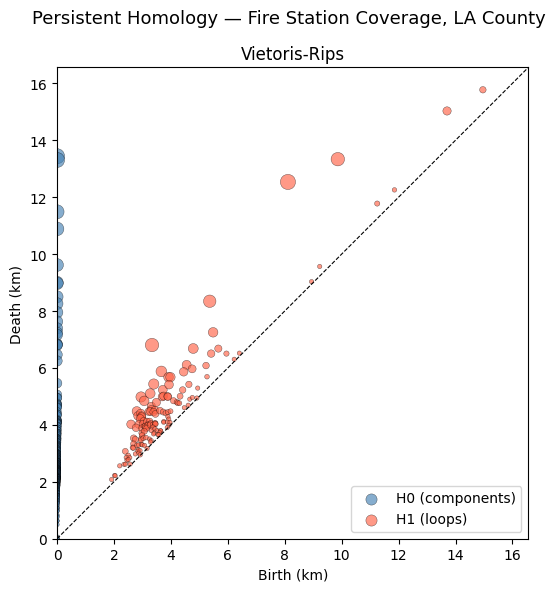

In [15]:
# Vietoris-Rips persistence diagram
fig, ax = plt.subplots(figsize=(7, 6))

for dim_key, color, label in [
    ("H0", "steelblue", "H0 (components)"),
    ("H1", "tomato",    "H1 (loops)"),
]:
    pairs = diag_rips[dim_key]
    if pairs:
        arr = np.array(pairs) / 1000  # → km
        birth, death = arr[:, 0], arr[:, 1]
        persistence = death - birth

        ax.scatter(birth, death,
                   c=color,
                   s=np.clip(persistence / persistence.max() * 120, 10, 120),
                   alpha=0.65, edgecolors="k", linewidths=0.3,
                   label=label)

# Diagonal reference line
all_vals = []
for dim_key in ["H0", "H1"]:
    if diag_rips[dim_key]:
        all_vals.extend(np.array(diag_rips[dim_key]).flatten())

if all_vals:
    lim = (np.array(all_vals).max() / 1000) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")

ax.set_xlabel("Birth (km)")
ax.set_ylabel("Death (km)")
ax.set_title("Vietoris-Rips")
ax.legend(loc="lower right")

plt.suptitle("Persistent Homology — Fire Station Coverage, LA County",
             fontsize=13)
plt.tight_layout()
# plt.savefig("../../results/FireStations_persistence_diagram(vietoris-rips).png", dpi=150, bbox_inches="tight")
plt.show()

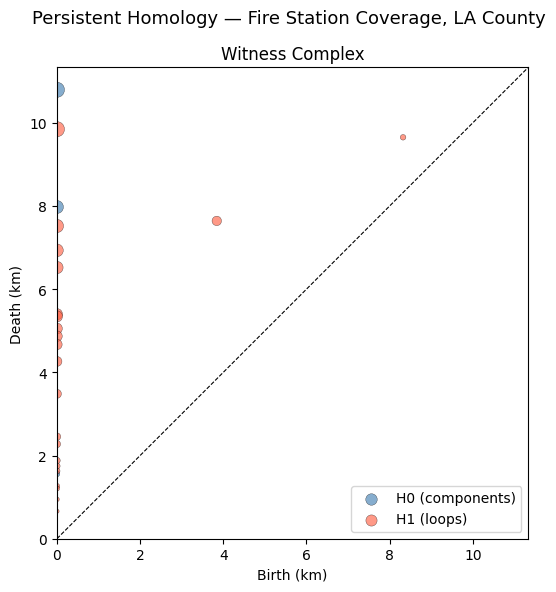

In [16]:
# Witness persistence diagram
fig, ax = plt.subplots(figsize=(7, 6))

for dim_key, color, label in [
    ("H0", "steelblue", "H0 (components)"),
    ("H1", "tomato",    "H1 (loops)"),
]:
    pairs = diag_wit[dim_key]
    if pairs:
        # Witness complex stores squared distances (m²); sqrt → metres → km
        arr = np.sqrt(np.array(pairs)) / 1000
        birth, death = arr[:, 0], arr[:, 1]
        persistence = death - birth

        ax.scatter(birth, death,
                   c=color,
                   s=np.clip(persistence / persistence.max() * 120, 10, 120),
                   alpha=0.65, edgecolors="k", linewidths=0.3,
                   label=label)

all_vals = []
for dim_key in ["H0", "H1"]:
    if diag_wit[dim_key]:
        all_vals.extend((np.sqrt(np.array(diag_wit[dim_key])) / 1000).flatten())

if all_vals:
    lim = max(all_vals) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")

ax.set_xlabel("Birth (km)")
ax.set_ylabel("Death (km)")
ax.set_title("Witness Complex")
ax.legend(loc="lower right")

plt.suptitle("Persistent Homology — Fire Station Coverage, LA County", fontsize=13)
plt.tight_layout()
# plt.savefig("../../results/FireStations_persistence_diagram(witness).png", dpi=150, bbox_inches="tight")
plt.show()


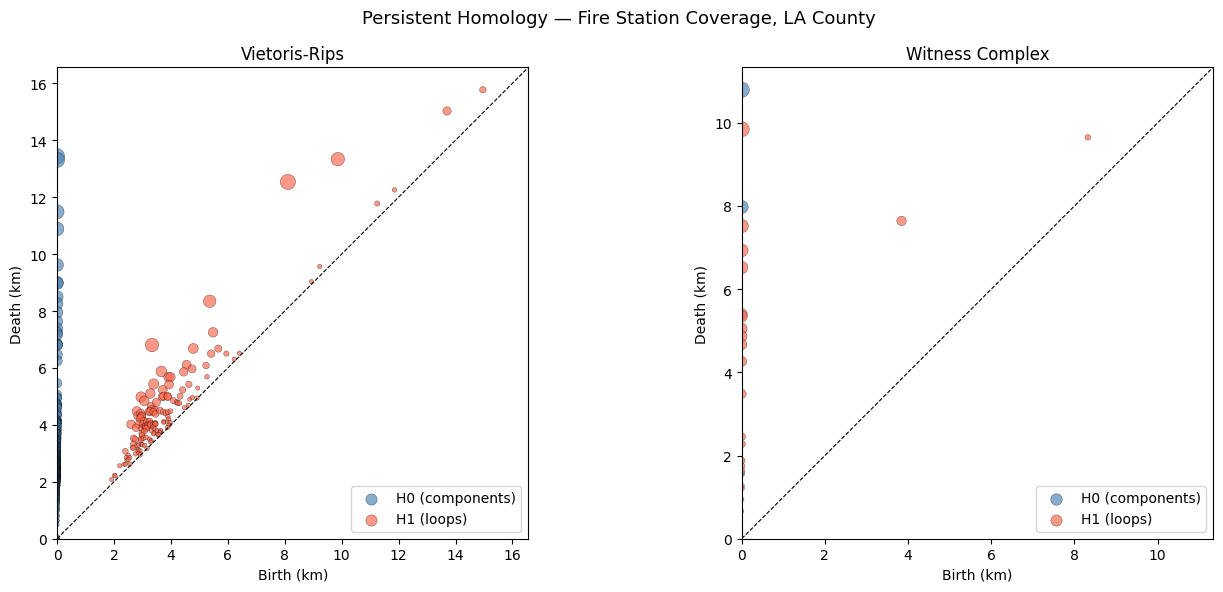

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── shared helper ──────────────────────────────────────────────────────────────
def plot_persistence(ax, diag, title, sqrt_scale=False):
    all_vals = []

    for dim_key, color, label in [
        ("H0", "steelblue", "H0 (components)"),
        ("H1", "tomato",    "H1 (loops)"),
    ]:
        pairs = diag[dim_key]
        if not pairs:
            continue

        arr = np.array(pairs)
        arr = (np.sqrt(arr) / 1000) if sqrt_scale else (arr / 1000)
        birth, death = arr[:, 0], arr[:, 1]
        persistence = death - birth

        ax.scatter(
            birth, death,
            c=color,
            s=np.clip(persistence / persistence.max() * 120, 10, 120),
            alpha=0.65, edgecolors="k", linewidths=0.3,
            label=label,
        )
        all_vals.extend(arr.flatten())

    if all_vals:
        lim = max(all_vals) * 1.05
        ax.plot([0, lim], [0, lim], "k--", lw=0.8)
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect("equal")

    ax.set_xlabel("Birth (km)")
    ax.set_ylabel("Death (km)")
    ax.set_title(title)
    ax.legend(loc="lower right")


# ── draw both panels ───────────────────────────────────────────────────────────
plot_persistence(axes[0], diag_rips, "Vietoris-Rips",   sqrt_scale=False)
plot_persistence(axes[1], diag_wit,  "Witness Complex",  sqrt_scale=True)

fig.suptitle(
    "Persistent Homology — Fire Station Coverage, LA County",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(
    "../../results/FireStations_persistence_diagram_combined.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

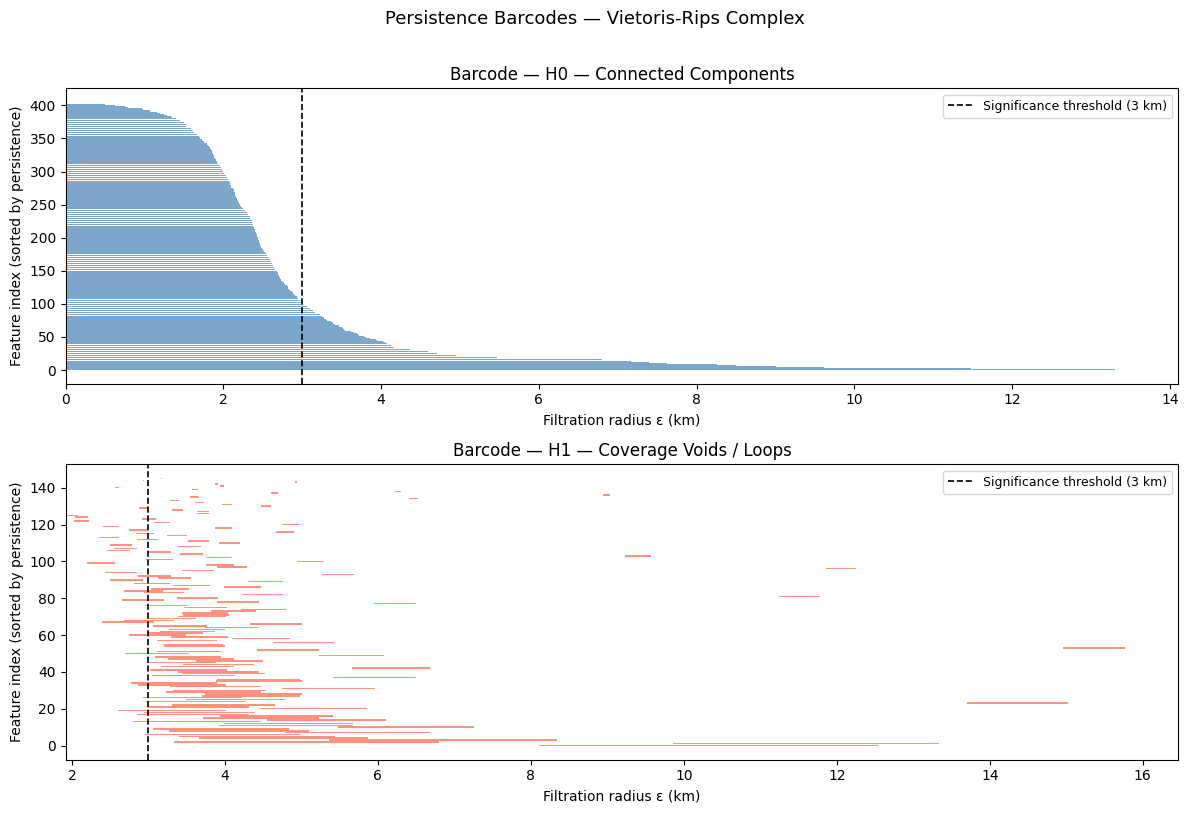

In [18]:
# Vietoris-Rips barcodes
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"H0": "steelblue", "H1": "tomato"}
labels = {"H0": "H0 — Connected Components", "H1": "H1 — Coverage Voids / Loops"}

for ax, dim_key in zip(axes, ["H0", "H1"]):
    pairs = sorted(diag_rips[dim_key], key=lambda x: x[1] - x[0], reverse=True)
    for i, (b, d) in enumerate(pairs):
        ax.barh(i, (d - b) / 1000, left=b / 1000,
                color=colors[dim_key], alpha=0.7, height=0.8)

    ax.axvline(H1_SIG_THRESHOLD_M / 1000, color="black", linestyle="--", lw=1.2,
               label=f"Significance threshold ({H1_SIG_THRESHOLD_M/1000:.0f} km)")
    ax.set_xlabel("Filtration radius ε (km)")
    ax.set_ylabel("Feature index (sorted by persistence)")
    ax.set_title(f"Barcode — {labels[dim_key]}")
    ax.legend(fontsize=9)

plt.suptitle("Persistence Barcodes — Vietoris-Rips Complex", fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig("../../results/FireStations_barcodes.png", dpi=150, bbox_inches="tight")
plt.show()


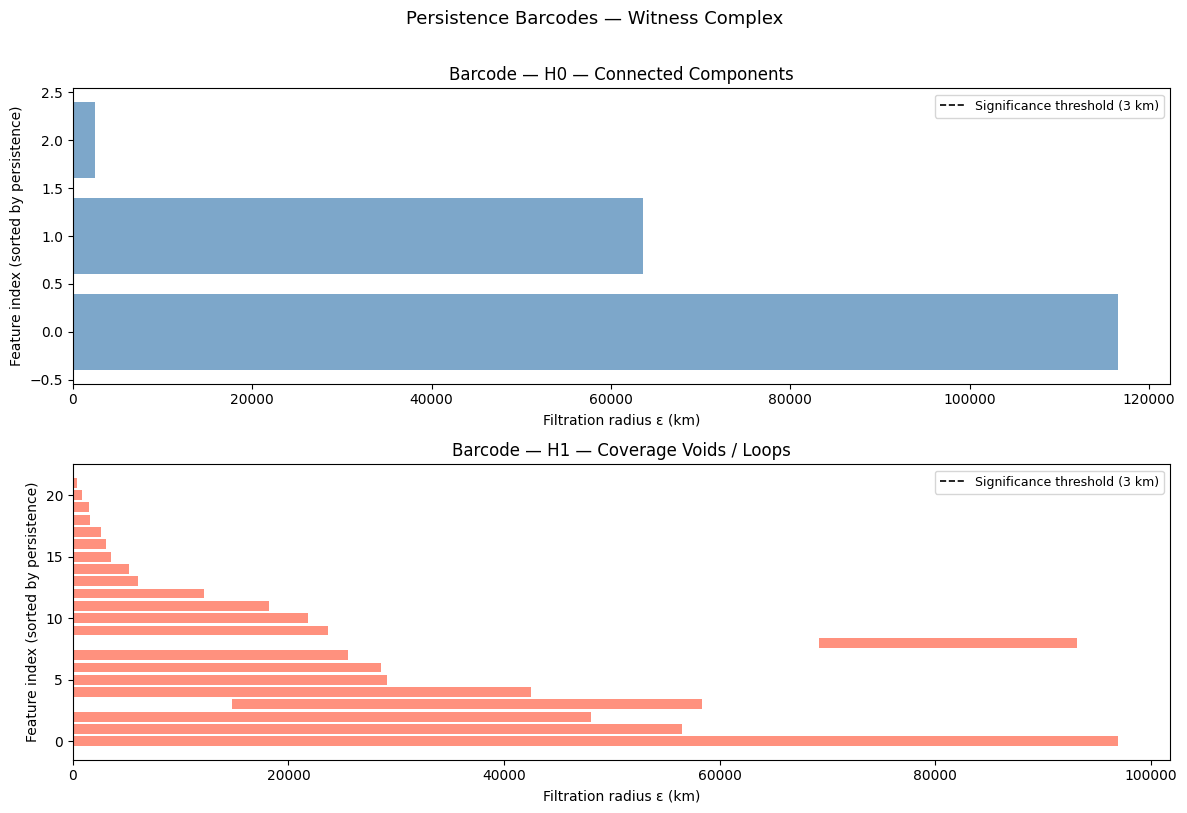

In [19]:
# Witness barcodes
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"H0": "steelblue", "H1": "tomato"}
labels = {"H0": "H0 — Connected Components", "H1": "H1 — Coverage Voids / Loops"}

for ax, dim_key in zip(axes, ["H0", "H1"]):
    pairs = sorted(diag_wit[dim_key], key=lambda x: x[1] - x[0], reverse=True)
    for i, (b, d) in enumerate(pairs):
        ax.barh(i, (d - b) / 1000, left=b / 1000,
                color=colors[dim_key], alpha=0.7, height=0.8)

    ax.axvline(H1_SIG_THRESHOLD_M / 1000, color="black", linestyle="--", lw=1.2,
               label=f"Significance threshold ({H1_SIG_THRESHOLD_M/1000:.0f} km)")
    ax.set_xlabel("Filtration radius ε (km)")
    ax.set_ylabel("Feature index (sorted by persistence)")
    ax.set_title(f"Barcode — {labels[dim_key]}")
    ax.legend(fontsize=9)

plt.suptitle("Persistence Barcodes — Witness Complex", fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig("../../results/FireStations_barcodes.png", dpi=150, bbox_inches="tight")
plt.show()

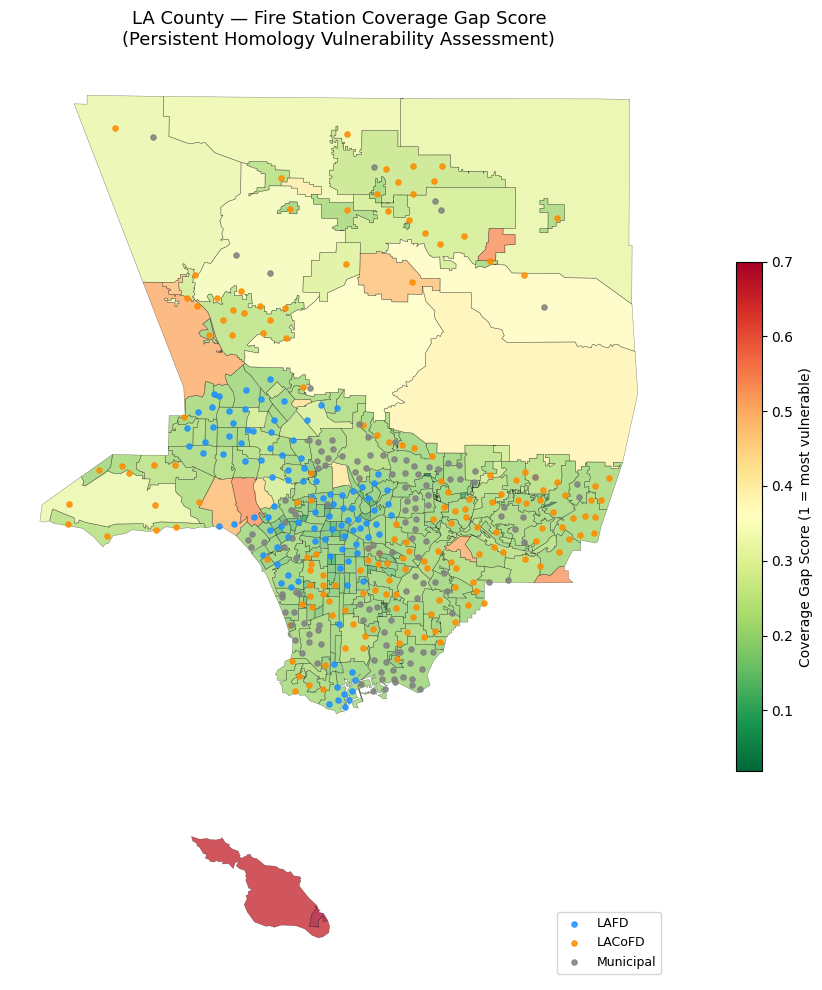

In [20]:
fig, ax = plt.subplots(figsize=(14, 10))

merged = county_proj.merge(
    vuln_df[["neighborhood", "coverage_gap_score"]],
    left_on="name", right_on="neighborhood", how="left"
)
merged["coverage_gap_score"] = merged["coverage_gap_score"].fillna(0)

merged.plot(column="coverage_gap_score", ax=ax, cmap="RdYlGn_r",
            legend=True, alpha=0.75,
            legend_kwds={"label": "Coverage Gap Score (1 = most vulnerable)",
                         "shrink": 0.55})

dept_col = stations_proj["department"]
for mask, color, label in [
    (dept_col == "LAFD",                               "dodgerblue", "LAFD"),
    (dept_col == "LACoFD",                             "darkorange", "LACoFD"),
    (~dept_col.isin(["LAFD", "LACoFD"]),               "grey",       "Municipal"),
]:
    sub = stations_proj[mask]
    ax.scatter(sub.geometry.x, sub.geometry.y,
               c=color, s=14, alpha=0.85, label=label, zorder=5)

county_proj.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.5)
ax.legend(fontsize=9, loc="lower right")
ax.set_title("LA County — Fire Station Coverage Gap Score\n"
             "(Persistent Homology Vulnerability Assessment)",
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
# plt.savefig("../../results/FireStations_spatial_coverage.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved: spatial_coverage.png")

In [21]:
# void_df.to_csv("coverage_voids.csv", index=False)
# vuln_df.to_csv("../../results/firestation_neighborhood_vulnerability.csv", index=False)
# betti_rips.to_csv("betti_numbers_rips.csv", index=False)
# betti_wit.to_csv("betti_numbers_witness.csv",  index=False)
# stats_all.to_csv("persistence_stats.csv",      index=False)

### Step 11 — Death Simplices & SVI Choropleth

| Figure | Content |
|---|---|
| **Figure A** | H1 death simplices (triangles) colored by death time |
| **Figure B** | SVI choropleth (amt. above avg.) + top H0 / H1 death simplices |

A **death simplex** is the specific geometric object (edge for H0, triangle for H1) whose addition to the complex kills a topological feature:
- **H0 death edge**: the edge that merges two previously disconnected clusters
- **H1 death triangle**: the triangle that fills in a coverage void (loop)

In [22]:
# ── How many top death simplices to highlight in Figure B ──
TOP_N_H0 = 15
TOP_N_H1 = 5

# ── Extract death simplices from the Rips SimplexTree ──
# persistence_pairs() returns (birth_simplex, death_simplex) as vertex-index lists:
#   H0: birth=[v], death=[u, w]   → death is an edge
#   H1: birth=[u,v], death=[u,v,w] → death is a triangle
h0_deaths = []
h1_deaths = []

for birth_simp, death_simp in st_rips.persistence_pairs():
    if len(death_simp) == 0:        # essential (infinite bar) — skip
        continue

    b_val = st_rips.filtration(birth_simp)
    d_val = st_rips.filtration(death_simp)
    pers  = d_val - b_val
    dim   = len(birth_simp) - 1    # 0 → H0, 1 → H1

    if dim == 0 and len(death_simp) == 2:    # H0 death: edge
        h0_deaths.append({
            "birth_val": b_val,
            "death_val": d_val,
            "pers"     : pers,
            "verts"    : death_simp,
            "coords"   : coords_m[death_simp],   # (2, 2)
        })

    elif dim == 1 and len(death_simp) == 3:  # H1 death: triangle
        h1_deaths.append({
            "birth_val": b_val,
            "death_val": d_val,
            "pers"     : pers,
            "verts"    : death_simp,
            "coords"   : coords_m[death_simp],   # (3, 2)
        })

# Sort by persistence descending
h0_deaths.sort(key=lambda x: -x["pers"])
h1_deaths.sort(key=lambda x: -x["pers"])

# ── SVI: compute amount above average ──
svi_mean = county_proj["rpl_themes"].mean()
county_proj = county_proj.copy()
county_proj["svi_above_avg"] = county_proj["rpl_themes"] - svi_mean

print(f"H0 death simplices (edges)     : {len(h0_deaths)}")
print(f"H1 death simplices (triangles) : {len(h1_deaths)}")
print(f"SVI mean (rpl_themes)          : {svi_mean:.4f}")
print(f"svi_above_avg range            : [{county_proj['svi_above_avg'].min():.3f}, {county_proj['svi_above_avg'].max():.3f}]")

if h1_deaths:
    print(f"\nTop 5 H1 death simplices by persistence:")
    print(f"{'Rank':>4}  {'Birth (km)':>10}  {'Death (km)':>10}  {'Pers (km)':>10}")
    for i, d in enumerate(h1_deaths[:5], 1):
        print(f"{i:>4}  {d['birth_val']/1000:>10.2f}  {d['death_val']/1000:>10.2f}  {d['pers']/1000:>10.2f}")

H0 death simplices (edges)     : 406
H1 death simplices (triangles) : 146
SVI mean (rpl_themes)          : 0.5288
svi_above_avg range            : [-0.529, 0.439]

Top 5 H1 death simplices by persistence:
Rank  Birth (km)  Death (km)   Pers (km)
   1        8.11       12.53        4.42
   2        9.86       13.33        3.47
   3        3.34        6.80        3.47
   4        5.36        8.34        2.98
   5        3.67        5.88        2.21


#### Figures A & B — Side by Side

| Figure | Content |
|---|---|
| **Figure A** | H1 death simplices (triangles) colored by death time |
| **Figure B** | SVI choropleth (amt. above avg.) + top H0 / H1 death simplices |

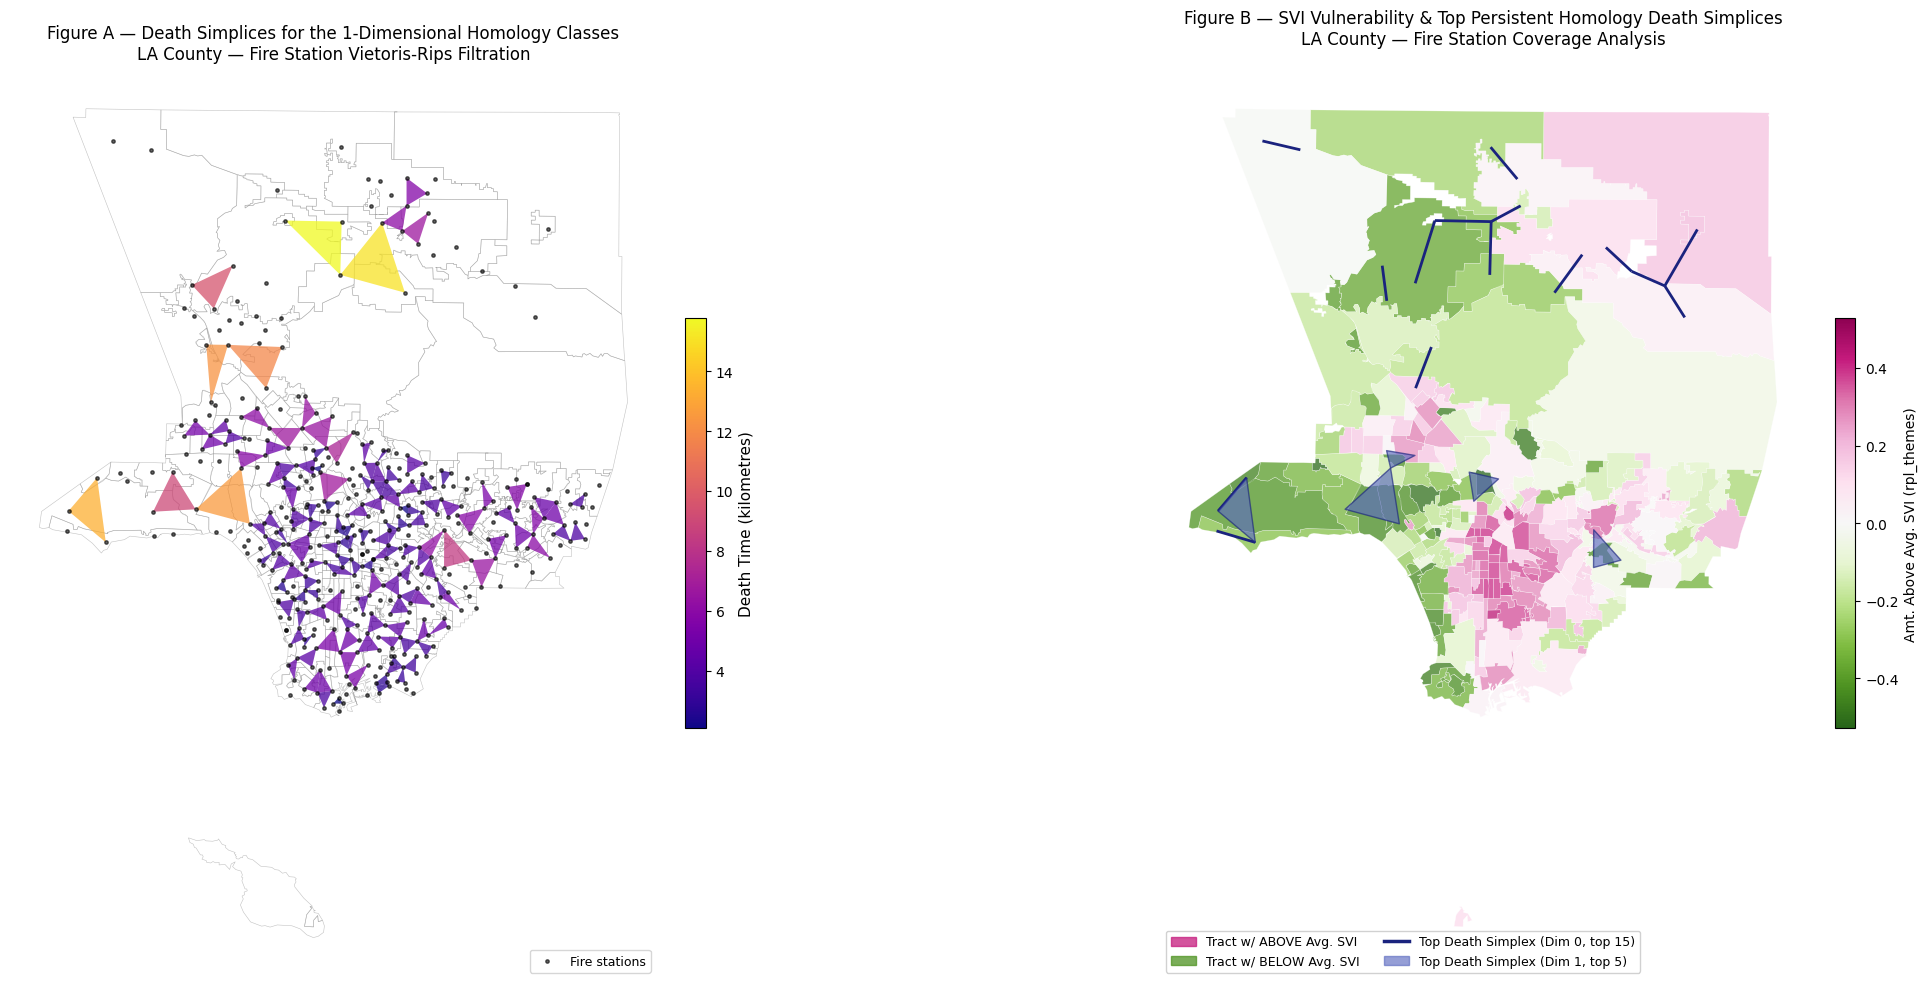

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 10))

# ── Figure A: H1 death simplices colored by death time ────────────────────
county_proj.boundary.plot(ax=ax1, color="#999999", linewidth=0.4, alpha=0.6)

if h1_deaths:
    death_vals_km = np.array([d["death_val"] / 1000 for d in h1_deaths])
    norm_a = mcolors.Normalize(vmin=death_vals_km.min(), vmax=death_vals_km.max())
    cmap_a = cm.plasma
    tri_colors = [cmap_a(norm_a(v)) for v in death_vals_km]
    poly_a = PolyCollection(
        [d["coords"] for d in h1_deaths],
        facecolors=tri_colors, edgecolors="none", alpha=0.75, zorder=3
    )
    ax1.add_collection(poly_a)
    sm_a = cm.ScalarMappable(cmap=cmap_a, norm=norm_a)
    sm_a.set_array([])
    cbar_a = plt.colorbar(sm_a, ax=ax1, shrink=0.45, pad=0.02)
    cbar_a.set_label("Death Time (kilometres)", fontsize=11)

ax1.scatter(
    stations_proj.geometry.x, stations_proj.geometry.y,
    c="black", s=6, alpha=0.6, zorder=5, label="Fire stations"
)
ax1.set_title(
    "Figure A — Death Simplices for the 1-Dimensional Homology Classes\n"
    "LA County — Fire Station Vietoris-Rips Filtration",
    fontsize=12,
)
ax1.legend(fontsize=9, loc="lower right")
ax1.set_axis_off()

# ── Figure B: SVI choropleth + top H0/H1 death simplices ──────────────────
abs_max = county_proj["svi_above_avg"].abs().max()
county_proj.plot(
    column="svi_above_avg", ax=ax2,
    cmap="PiYG_r", vmin=-abs_max, vmax=abs_max,
    legend=True, alpha=0.75,
    legend_kwds={"label": "Amt. Above Avg. SVI (rpl_themes)", "shrink": 0.45, "pad": 0.02},
)
county_proj.boundary.plot(ax=ax2, color="white", linewidth=0.3, alpha=0.5)

top_h0 = h0_deaths[:TOP_N_H0]
if top_h0:
    lc = LineCollection(
        [d["coords"] for d in top_h0],
        colors="#1a237e", linewidths=2.0, zorder=4,
        label=f"Top Death Simplex (Dim 0, top {TOP_N_H0})",
    )
    ax2.add_collection(lc)

top_h1 = h1_deaths[:TOP_N_H1]
if top_h1:
    poly_b = PolyCollection(
        [d["coords"] for d in top_h1],
        facecolors="#5c6bc0", edgecolors="#1a237e",
        linewidths=1.0, alpha=0.65, zorder=5,
        label=f"Top Death Simplex (Dim 1, top {TOP_N_H1})",
    )
    ax2.add_collection(poly_b)

above_patch = mpatches.Patch(color="#c51b7d", alpha=0.75, label="Tract w/ ABOVE Avg. SVI")
below_patch = mpatches.Patch(color="#4d9221", alpha=0.75, label="Tract w/ BELOW Avg. SVI")
h0_line     = plt.Line2D([0], [0], color="#1a237e", linewidth=2.5,
                          label=f"Top Death Simplex (Dim 0, top {TOP_N_H0})")
h1_patch    = mpatches.Patch(color="#5c6bc0", alpha=0.65,
                              label=f"Top Death Simplex (Dim 1, top {TOP_N_H1})")
ax2.legend(
    handles=[above_patch, below_patch, h0_line, h1_patch],
    loc="lower left", fontsize=9, framealpha=0.9, ncol=2,
)
ax2.set_title(
    "Figure B — SVI Vulnerability & Top Persistent Homology Death Simplices\n"
    "LA County — Fire Station Coverage Analysis",
    fontsize=12,
)
ax2.set_axis_off()

plt.tight_layout()
# plt.savefig("../../results/figures_AB_side_by_side.png", dpi=150, bbox_inches="tight")
plt.show()
